In [ ]:
import kagglehub
import os
import random
from PIL import Image

In [ ]:
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
path = ".."+path+"/New Plant Diseases Dataset(Augmented)"+"/New Plant Diseases Dataset(Augmented)"
train_path = path+"/train"
val_path = path+"/valid"

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.


Tomato___Target_Spot
256
256


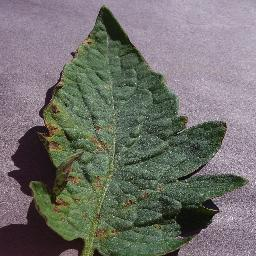

In [ ]:
classes = [name for name in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, name))]
class_name = random.choice(classes)
class_path = os.path.join(train_path, class_name)
img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

img = Image.open(img_path)

print(class_name)
print(img.width)
print(img.height)
img

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


In [ ]:
weight, bias = 0.7, 0.3

In [ ]:
X = torch.arange(0, 2, 0.02).unsqueeze(dim=1)
y = weight * X + bias
len(X), len(y)

(100, 100)

In [ ]:
train_split = int(0.8*len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [ ]:
class SampleModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weight = nn.Parameter(torch.randn(1, requires_grad = True, dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1, requires_grad = True, dtype=torch.float))
  def forward(self, x: torch.Tensor):
    return (self.weight * x) + self.bias


In [ ]:
torch.manual_seed(42)
model_first = SampleModel()

In [ ]:
model_first.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_first.parameters(), lr=0.00001)

In [ ]:
def plot_predictions(X_train, y_train, X_test, y_test, y_preds=None):
  plt.scatter(X_train, y_train, c ="b")
  plt.scatter(X_test, y_test, c = "g")
  if y_preds is not None:
    plt.scatter(X_test, y_preds, c="r")

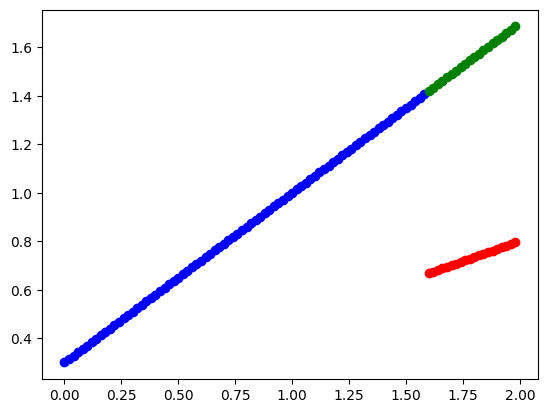

In [ ]:
with torch.inference_mode():
  y_preds = model_first(X_test)
plot_predictions(X_train, y_train, X_test, y_test, y_preds)

In [ ]:
torch.manual_seed(42)

epochs = 100

for epoch in range(epochs):
  model_first.train()

  y_pred = model_first(X_train)

  loss = loss_fn(y_pred, y_train)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_first.eval()
  with torch.inference_mode():
    test_pred = model_first(X_test)
    test_loss = loss_fn(test_pred, y_test)

  if epoch % 10 == 0:
    print(f"epoch {epoch} | loss {loss} | test loss {test_loss}")

epoch 0 | loss 0.4582051634788513 | test loss 0.8214906454086304
epoch 10 | loss 0.45804286003112793 | test loss 0.8212493062019348
epoch 20 | loss 0.457880437374115 | test loss 0.821008026599884
epoch 30 | loss 0.4577180743217468 | test loss 0.8207665681838989
epoch 40 | loss 0.4575556814670563 | test loss 0.8205251693725586
epoch 50 | loss 0.4573933184146881 | test loss 0.8202838897705078
epoch 60 | loss 0.45723095536231995 | test loss 0.820042610168457
epoch 70 | loss 0.4570685923099518 | test loss 0.8198012113571167
epoch 80 | loss 0.45690616965293884 | test loss 0.8195598721504211
epoch 90 | loss 0.4567438066005707 | test loss 0.8193184733390808


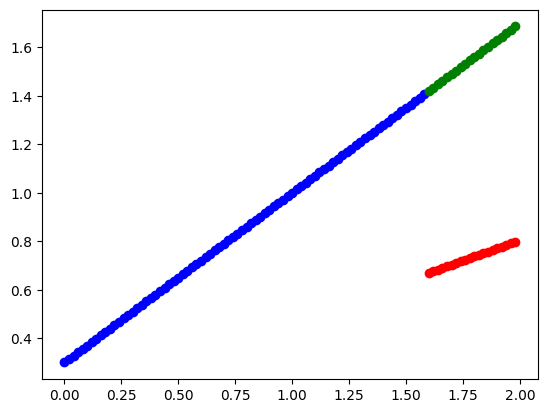

In [ ]:
with torch.inference_mode():
  y_preds = model_first(X_test)
plot_predictions(X_train, y_train, X_test, y_test, y_preds)

In [ ]:
model_first.state_dict()

OrderedDict([('weight', tensor([0.3375])), ('bias', tensor([0.1298]))])

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

In [ ]:
train_dataset = datasets.ImageFolder(root = train_path, transform=None)

In [ ]:
valid_dataset = datasets.ImageFolder(root = val_path, transform=data_transformer)

NameError: name 'data_transformer' is not defined

In [ ]:
# Define a basic transformation (you might want to customize this)
data_transformer = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to a consistent size
    transforms.ToTensor(),          # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize images
])

In [ ]:
valid_dataset = datasets.ImageFolder(root = val_path, transform=data_transformer)

In [ ]:
len(train_dataset), len(valid_dataset)

(70295, 17572)

In [ ]:
transformed_img = data_transformer(img)
print(transformed_img)

tensor([[[ 0.0569,  0.0569,  0.0569,  ...,  0.6734,  0.6563,  0.6392],
         [ 0.0741,  0.0912,  0.0912,  ...,  0.7077,  0.6734,  0.6221],
         [ 0.0227,  0.0569,  0.0741,  ...,  0.7248,  0.6906,  0.6392],
         ...,
         [-1.2103, -1.2103, -1.2103,  ...,  0.0569, -0.0972,  0.2282],
         [-1.1760, -1.1760, -1.1932,  ...,  0.2624,  0.1083,  0.2967],
         [-1.1589, -1.1589, -1.1589,  ...,  0.0398,  0.4508,  0.3823]],

        [[-0.0749, -0.0749, -0.0749,  ...,  0.6779,  0.6604,  0.6429],
         [-0.0574, -0.0399, -0.0399,  ...,  0.7129,  0.6779,  0.6254],
         [-0.1099, -0.0749, -0.0574,  ...,  0.7304,  0.6954,  0.6429],
         ...,
         [-1.5105, -1.5105, -1.5105,  ..., -0.0574, -0.2150,  0.1176],
         [-1.5105, -1.5105, -1.5280,  ...,  0.1527, -0.0049,  0.1877],
         [-1.5105, -1.5105, -1.5105,  ..., -0.0749,  0.3452,  0.2752]],

        [[ 0.5136,  0.5136,  0.5136,  ...,  1.1585,  1.1411,  1.1237],
         [ 0.5311,  0.5485,  0.5485,  ...,  1

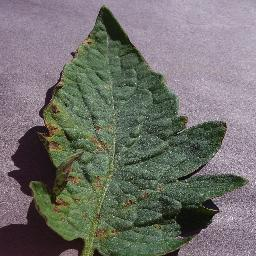

In [ ]:
img

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle = True, num_workers=2)

In [ ]:
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle = False, num_workers=2)

In [ ]:
len(train_loader), len(valid_loader)

(2197, 550)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
dummy_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [ ]:
train_dataset = datasets.ImageFolder(root = train_path, transform=dummy_transform)

In [ ]:
def compute_mean_std(dataset, batch_size=16, num_workers=2):
  loader = DataLoader(dataset, batch_size=batch_size, shuffle = False, num_workers=2)
  channel_sum = torch.zeros(3, device=device)
  channel_sqsum = torch.zeros(3, device=device)
  pixel_count = 0

  for x, _ in loader:
    x = x.to(device)
    b, c, h, w = x.shape
    pixel_count+= h * w * b
    channel_sum += x.sum(dim=[0, 2, 3])
    channel_sqsum += (x**2).sum(dim=[0, 2, 3])

  mean = channel_sum / pixel_count
  std = torch.sqrt(channel_sqsum/ pixel_count - mean ** 2)
  return  mean, std

In [ ]:
mean, std = compute_mean_std(train_dataset)
mean = mean.tolist()
std = std.tolist()

In [ ]:
mean, std

([0.47596338391304016, 0.5003822445869446, 0.42664194107055664],
 [0.21028108894824982, 0.18884526193141937, 0.22626696527004242])

In [ ]:
mean = [0.47596338391304016, 0.5003822445869446, 0.42664194107055664]
std = [0.21028108894824982, 0.18884526193141937, 0.22626696527004242]

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [ ]:
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [ ]:
train_dataset = datasets.ImageFolder(root = train_path, transform=train_transform)

In [ ]:
test_dataset = datasets.ImageFolder(root = train_path, transform=test_transform)

In [ ]:

train_loader = DataLoader(train_dataset, batch_size=32, shuffle = True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle = False, num_workers=2)

In [ ]:
class SimpleCNN(nn.Module):
  def __init__(self, in_features, out_features, hidden_units):
    super().__init__()
    self.layer = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=in_features, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=out_features)
    )

  def forward(self, x):
    return self.layer(x)

In [ ]:
model = SimpleCNN(3*224*224, 38, 256)
model.to(device)

SimpleCNN(
  (layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=150528, out_features=256, bias=True)
    (2): Linear(in_features=256, out_features=38, bias=True)
  )
)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

In [ ]:
torch.manual_seed(42)
epoch = 2

for epoch in range(epochs):
  print(f"Epoch: {epoch+1}")
  print("----------------------")
  train_loss = 0
  test_loss = 0
  for X, y in train_loader:
    X, y = X.to(device), y.to(device)
    model.train()

    y_pred = model(X)

    loss = loss_fn(y_pred, y)
    train_loss+=loss.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()
  train_loss /= len(train_loader)
  model.eval()
  with torch.inference_mode():
    for X_test, y_test in test_loader:
      X_test, y_test = X_test.to(device), y_test.to(device)
      y_test_pred = model(X_test)
      test_loss+= loss_fn(y_test_pred, y_test)
    test_loss /= len(test_loader)



  print(f"train loss: {train_loss} | test loss: {test_loss}")


Epoch: 1
----------------------


In [ ]:
import torchvision.transforms as transforms

mean = [0.47596338391304016, 0.5003822445869446, 0.42664194107055664]
std = [0.21028108894824982, 0.18884526193141937, 0.22626696527004242]

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [ ]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(root = train_path, transform=train_transform)
test_dataset = datasets.ImageFolder(root = train_path, transform=test_transform)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle = True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle = False, num_workers=2)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

In [ ]:
import torch

torch.manual_seed(42)
epochs = 10  # Training for 10 epochs

for epoch in range(epochs):
    print(f"Epoch: {epoch+1}")
    print("----------------------")

    train_loss = 0
    test_loss = 0

    # Training loop
    model.train()
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Evaluation loop
    model.eval()
    with torch.no_grad():
        for X_test, y_test in test_loader:
            X_test, y_test = X_test.to(device), y_test.to(device)
            y_test_pred = model(X_test)
            loss = loss_fn(y_test_pred, y_test)
            test_loss += loss.item()

    test_loss /= len(test_loader)

    print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}\n")


Epoch: 1
----------------------
Train Loss: nan | Test Loss: nan

Epoch: 2
----------------------
Train Loss: nan | Test Loss: nan

Epoch: 3
----------------------
Train Loss: nan | Test Loss: nan

Epoch: 4
----------------------
Train Loss: nan | Test Loss: nan

Epoch: 5
----------------------
Train Loss: nan | Test Loss: nan

Epoch: 6
----------------------
Train Loss: nan | Test Loss: nan

Epoch: 7
----------------------
Train Loss: nan | Test Loss: nan

Epoch: 8
----------------------
Train Loss: nan | Test Loss: nan

Epoch: 9
----------------------


In [ ]:
import torch

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

mean = [0.4760, 0.5004, 0.4266]

std = [0.1775, 0.1509, 0.1960]

train_transform = transforms.Compose([

transforms.Resize ((224, 224)),

transforms.RandomHorizontalFlip(p=0.5),

transforms.RandomVerticalFlip (p=0.2),

transforms.RandomRotation (degrees=15),

transforms.ToTensor(),

transforms.Normalize(mean, std)

])

val_transform = transforms.Compose([

transforms.Resize((224, 224)),

transforms.ToTensor(),

transforms.Normalize(mean, std)
])

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PlantDiseaseCNN(nn.Module):
    def __init__(self, num_classes):
        super(PlantDiseaseCNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)

        # Pooling
        self.pool = nn.MaxPool2d(2, 2)

        # Dropout
        self.dropout = nn.Dropout(0.5)

        # Fully connected layers (for 224x224 input images)
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # [32, 112, 112]
        x = self.pool(F.relu(self.conv2(x)))  # [64, 56, 56]
        x = self.pool(F.relu(self.conv3(x)))  # [128, 28, 28]

        x = x.view(x.size(0), -1)  # flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Example: PlantVillage has 38 classes
num_classes = 38
model = PlantDiseaseCNN(num_classes)
print(model)


PlantDiseaseCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=100352, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=38, bias=True)
)


In [ ]:
import torch
import kagglehub

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Define paths to the dataset
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
path = ".."+path+"/New Plant Diseases Dataset(Augmented)"+"/New Plant Diseases Dataset(Augmented)"
train_path = path+"/train"
val_path = path+"/valid"

mean = [0.4760, 0.5004, 0.4266]

std = [0.2103, 0.1888, 0.2263] # Updated std values

train_transform = transforms.Compose([

transforms.Resize((224, 224)),

transforms.RandomHorizontalFlip(0.5),

transforms.ToTensor(),

transforms.Normalize(mean=mean, std=std),

transforms.RandomErasing (p=0.5, scale=(0.02,0.2))

])
test_transform = transforms.Compose([

transforms.Resize((224,224)),

transforms.ToTensor(),

transforms.Normalize(mean=mean, std=std)

])

train_dataset = datasets.ImageFolder(root = train_path, transform=train_transform)

test_dataset = datasets.ImageFolder(root = train_path, transform=test_transform)

train_loader = DataLoader (train_dataset, batch_size=32, shuffle = True, num_workers=2)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle = True, num_workers=2)

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.


In [ ]:
# Get the class counts from the training dataset
train_class_counts = {}
for _, label in train_dataset:
    if train_dataset.classes[label] not in train_class_counts:
        train_class_counts[train_dataset.classes[label]] = 0
    train_class_counts[train_dataset.classes[label]] += 1

# Sort the class counts alphabetically for consistent plotting
sorted_classes = sorted(train_class_counts.keys())
sorted_counts = [train_class_counts[class_name] for class_name in sorted_classes]

KeyboardInterrupt: 

In [ ]:
import torch

from torch.utils.data import DataLoader

from torchvision import datasets, transforms

import kagglehub

import os

import torch.nn as nn

import torch.nn.functional as F

import torch.optim as optim

#Download dataset

path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

dataset_path= os.path.join(

path, "New Plant Diseases Dataset(Augmented)", "New Plant Diseases Dataset(Augmented)"

)
train_path= os.path.join(dataset_path, "train")

valid_path=os.path.join(dataset_path, "valid")

#Transforms or Dataloader

mean=[0.4757, 0.5001, 0.4264]

std = [0.1847, 0.1592, 0.2024]

data_transform =transforms.Compose([

transforms.Resize((128, 128)),

transforms.ToTensor(),

transforms.Normalize(mean=mean, std=std)

])

train_dataset = datasets.ImageFolder(root=train_path, transform=data_transform)

valid_dataset = datasets.ImageFolder(root=valid_path, transform=data_transform)

train_loader=DataLoader(train_dataset, batch_size=32, shuffle = True, num_workers=2)

valid_loader=DataLoader(valid_dataset, batch_size=32, shuffle = False, num_workers=2)

print(f"Training images: {len(train_dataset)}")

print(f"Validation images: {len(valid_dataset)}")

print(f"classes: {train_dataset.classes}")



#CNN model

class PlantCNN(nn.Module):
  def __init__(self, num_classes):
    super(PlantCNN, self).__init__()
    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
    self.bn1= nn.BatchNorm2d(32)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
    self.bn2=nn.BatchNorm2d(64)
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
    self.bn3 =nn.BatchNorm2d(128)
    self.pool = nn. MaxPool2d(2, 2)
    self.dropout= nn.Dropout(0.5)
    self.fc1 = nn.Linear(128 *16 * 16, 256)
    self.fc2 = nn.Linear(256, num_classes)
  def forward(self, x):
    x= self.pool(F.relu(self.bn1(self.conv1(x))))
    x= self.pool(F.relu(self.bn2(self.conv2(x))))
    x= self.pool(F.relu(self.bn3(self.conv3(x))))
    x = x.view(x.size(0), -1)
    x= F.relu(self.fc1(x))
    x= self.dropout(x)
    x= self.fc2(x)
    return x

device= torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes=len(train_dataset.classes)

model = PlantCNN(num_classes).to(device)

criterion=nn.CrossEntropyLoss()

optimizer= optim.Adam(model.parameters(), lr=0.001)

  #training part
epochs = 10


for epoch in range(epochs):
  model.train()
  train_loss, correct, total=0.0, 0, 0

  for images, labels in train_loader:
      images, labels = images.to(device), labels.to(device)

      outputs = model(images)
      loss= criterion(outputs, labels)

      optimizer.zero_grad()

      loss.backward()

      optimizer.step()

      train_loss += loss.item()* images.size(0)

      _,predicted = outputs.max(1)

      total += labels.size(0)

      correct += predicted.eq(labels).sum().item()

  train_loss /= len(train_dataset)

  train_acc= 100. * correct / total

  # Evaluation part
  model.eval()
  valid_loss, correct, total = 0.0, 0, 0
  with torch.no_grad():
      for images, labels in valid_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          loss = criterion(outputs, labels)

          valid_loss += loss.item() * images.size(0)
          _, predicted = outputs.max(1)
          total += labels.size(0)
          correct += predicted.eq(labels).sum().item()

  valid_loss /= len(valid_dataset)
  valid_acc = 100. * correct / total

  print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Valid Loss: {valid_loss:.4f}, Valid Acc: {valid_acc:.2f}%")



Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
Training images: 70295
Validation images: 17572
classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato

In [ ]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=38):
        super(SimpleCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Instead of hardcoding, use adaptive pooling to always reduce to (128, 4, 4)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.adaptive_pool(x)   # Ensure fixed size before flatten
        x = self.fc_layers(x)
        return x


# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = SimpleCNN(num_classes=38).to(device)


In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)


In [ ]:
# Define paths to the dataset
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
path = ".."+path+"/New Plant Diseases Dataset(Augmented)"+"/New Plant Diseases Dataset(Augmented)"
train_path = path+"/train"
val_path = path+"/valid"

mean = [0.4760, 0.5004, 0.4266]

std = [0.2103, 0.1888, 0.2263] # Updated std values

train_transform = transforms.Compose([

transforms.Resize((224, 224)),

transforms.RandomHorizontalFlip(0.5),

transforms.ToTensor(),

transforms.Normalize(mean=mean, std=std),

transforms.RandomErasing (p=0.5, scale=(0.02,0.2))

])
test_transform = transforms.Compose([

transforms.Resize((224,224)),

transforms.ToTensor(),

transforms.Normalize(mean=mean, std=std)

])

train_dataset = datasets.ImageFolder(root = train_path, transform=train_transform)

# Use val_path for the validation dataset
valid_dataset = datasets.ImageFolder(root = val_path, transform=test_transform)

train_loader = DataLoader (train_dataset, batch_size=32, shuffle = True, num_workers=2)

valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle = False, num_workers=2)

100%|██████████| 2.70G/2.70G [01:08<00:00, 42.1MB/s]

Extracting files...


In [ ]:
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    train_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    avg_train_loss = train_loss / len(train_loader)

    # Validation loop using valid_loader
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in valid_loader:  # Use valid_loader here
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = loss_fn(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    avg_val_loss = val_loss / len(valid_loader) # Use valid_loader here

    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
          f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%')

Epoch [1/10], Train Loss: 1.2737, Train Acc: 60.62%, Val Loss: 0.8862, Val Acc: 71.82%
Epoch [2/10], Train Loss: 0.7759, Train Acc: 75.40%, Val Loss: 0.7206, Val Acc: 76.50%
Epoch [3/10], Train Loss: 0.5644, Train Acc: 82.01%, Val Loss: 0.4594, Val Acc: 85.23%
Epoch [4/10], Train Loss: 0.4372, Train Acc: 85.99%, Val Loss: 0.3647, Val Acc: 88.16%
Epoch [5/10], Train Loss: 0.3536, Train Acc: 88.63%, Val Loss: 0.2803, Val Acc: 90.79%
Epoch [6/10], Train Loss: 0.2908, Train Acc: 90.64%, Val Loss: 0.2539, Val Acc: 91.71%
Epoch [7/10], Train Loss: 0.2473, Train Acc: 91.97%, Val Loss: 0.2605, Val Acc: 91.63%
Epoch [8/10], Train Loss: 0.2138, Train Acc: 93.05%, Val Loss: 0.1892, Val Acc: 93.51%
Epoch [9/10], Train Loss: 0.1876, Train Acc: 93.81%, Val Loss: 0.1641, Val Acc: 94.53%
Epoch [10/10], Train Loss: 0.1659, Train Acc: 94.49%, Val Loss: 0.1640, Val Acc: 94.49%
